# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

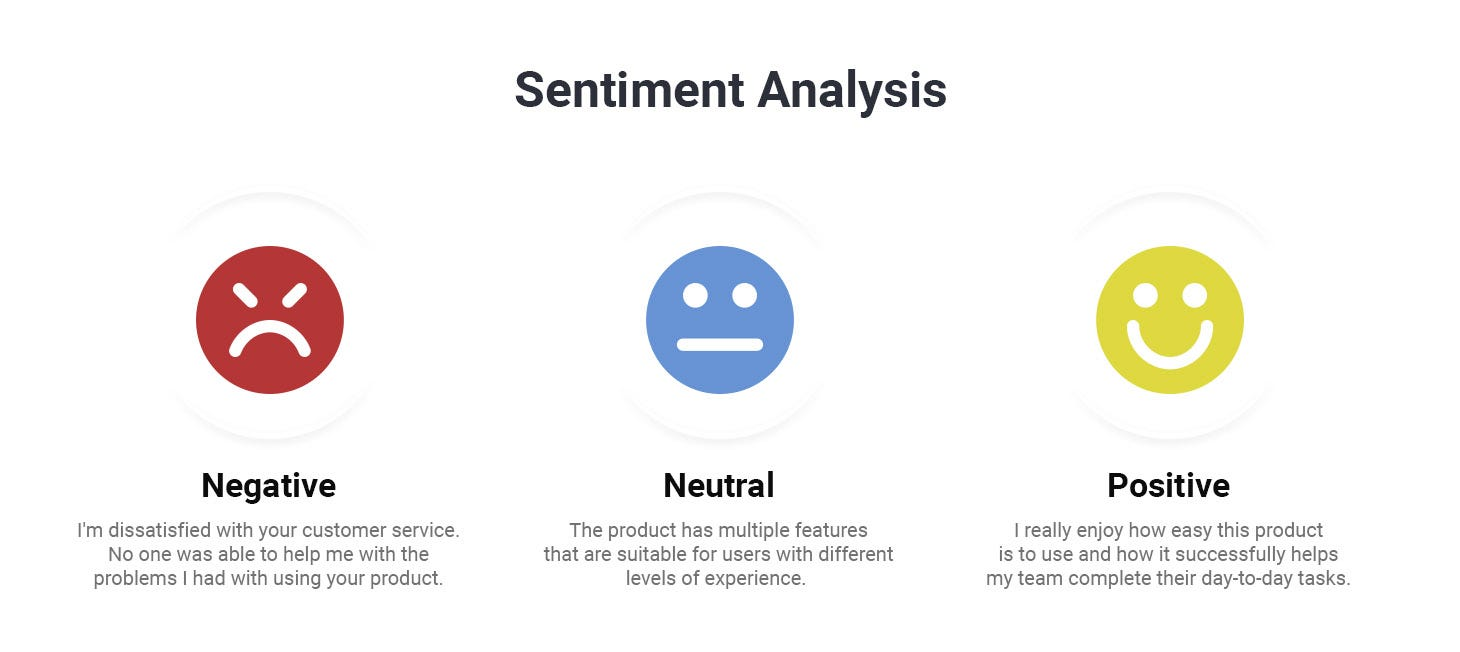

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [ ]:
# Load the dataset
import pandas as pd

data = pd.read_csv('/content/DisneylandReviews.csv', encoding='latin-1')
data

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [ ]:
#Check for missing values
data.isna().sum()

,0
Review_ID,0
Rating,0
Year_Month,0
Reviewer_Location,0
Review_Text,0
Branch,0


In [ ]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [ ]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [ ]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [ ]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34124,)
test_data size: (8532,)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.54      0.58       720
     neutral       0.48      0.18      0.26      1035
    positive       0.88      0.98      0.92      6777

    accuracy                           0.84      8532
   macro avg       0.66      0.56      0.59      8532
weighted avg       0.81      0.84      0.81      8532



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

In [1]:
import pandas as pd
import numpy as np
import re
import glob
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Show all CSV files in the current folder
csv_files = glob.glob("*.csv")

print("CSV files found:")
print(csv_files)

CSV files found:
['tallest_people_in_the_world.csv', 'advertising.csv', 'c.csv', 'cleaned_sales_data.csv', 'Random Tweets from Pakistan- Cleaned- Anonymous.csv', 'market_pipe_thickness_loss_dataset.csv', 'KNN_Project_Data.csv', 'USA_Housing.csv', 'Amazon_Unlocked_Mobile.csv', 'sales_data_minmax.csv', 'CC_GENERAL.csv', 'sales_data_zscore.csv', 'market_pipe_thickness_loss_dataset-2.csv', 'Chocolate_Sales.csv', 'loan_data.csv', 'titanic_train.csv']


In [2]:
import pandas as pd

file_path = "Amazon_Unlocked_Mobile.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Dataset shape: (413840, 6)

Columns:
Index(['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews',
       'Review Votes'],
      dtype='object')

First 5 rows:


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [3]:
# Keep only the required columns
df = df[["Reviews", "Rating"]].copy()

# Step 1: Remove missing values
df = df.dropna(subset=["Reviews", "Rating"])

# Step 2: Remove duplicate reviews
df = df.drop_duplicates(subset=["Reviews"])

# Convert reviews to strings
df["Reviews"] = df["Reviews"].astype(str)

# Function for text preprocessing
def preprocess_text(text):
    # Step 3: Convert text to lowercase
    text = text.lower()

    # Step 4: Remove URLs, HTML tags, numbers, and punctuation
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)

    # Step 5: Remove English stopwords
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]

    return " ".join(words)

# Apply preprocessing
df["Cleaned_Reviews"] = df["Reviews"].apply(preprocess_text)

# Remove reviews that became empty
df = df[df["Cleaned_Reviews"].str.strip() != ""]

# Create sentiment labels
def create_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Rating"].apply(create_sentiment)

print("Preprocessing completed successfully!")
print("Dataset shape after preprocessing:", df.shape)

print("\nSentiment distribution:")
print(df["Sentiment"].value_counts())

print("\nSample after preprocessing:")
display(df[["Reviews", "Cleaned_Reviews", "Rating", "Sentiment"]].head())

Preprocessing completed successfully!
Dataset shape after preprocessing: (162270, 4)

Sentiment distribution:
Sentiment
Positive    103610
Negative     44311
Neutral      14349
Name: count, dtype: int64

Sample after preprocessing:


,Reviews,Cleaned_Reviews,Rating,Sentiment
0,I feel so LUCKY to have found this used (phone...,feel lucky used phone used hard phone line upg...,5,Positive
1,"nice phone, nice up grade from my pantach revu...",nice phone nice grade pantach revue clean set ...,4,Positive
2,Very pleased,pleased,5,Positive
3,It works good but it goes slow sometimes but i...,works good goes slow good phone love,4,Positive
4,Great phone to replace my lost phone. The only...,great phone replace lost phone thing volume bu...,4,Positive


In [4]:
# Task 2: Split the data into training and testing sets

# Input feature
X = df["Cleaned_Reviews"]

# Target label
y = df["Sentiment"]

# Split: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data split completed successfully!")
print("Training data size:", len(X_train))
print("Testing data size:", len(X_test))

print("\nTraining sentiment distribution:")
print(y_train.value_counts())

print("\nTesting sentiment distribution:")
print(y_test.value_counts())

Data split completed successfully!
Training data size: 129816
Testing data size: 32454

Training sentiment distribution:
Sentiment
Positive    82888
Negative    35449
Neutral     11479
Name: count, dtype: int64

Testing sentiment distribution:
Sentiment
Positive    20722
Negative     8862
Neutral      2870
Name: count, dtype: int64


In [6]:
# Task 3: Feature Extraction using TF-IDF

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

# Learn the vocabulary from training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the same vocabulary
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF feature extraction completed successfully!")
print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)
print("Number of extracted features:", len(tfidf.get_feature_names_out()))

TF-IDF feature extraction completed successfully!
Training matrix shape: (129816, 20000)
Testing matrix shape: (32454, 20000)
Number of extracted features: 20000


In [7]:
# Task 4: Train a Naive Bayes Classifier

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [8]:
# Task 5: Evaluate the model on the test set

# Predict the sentiment of test reviews
y_pred = model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model evaluation completed successfully!")
print("Accuracy:", accuracy)
print("Accuracy percentage: {:.2f}%".format(accuracy * 100))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Model evaluation completed successfully!
Accuracy: 0.8259998767486288
Accuracy percentage: 82.60%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.79      0.78      8862
     Neutral       0.35      0.02      0.04      2870
    Positive       0.85      0.95      0.90     20722

    accuracy                           0.83     32454
   macro avg       0.66      0.59      0.57     32454
weighted avg       0.78      0.83      0.79     32454



Confusion Matrix:
[[ 6979    44  1839]
 [ 1076    59  1735]
 [  887    66 19769]]


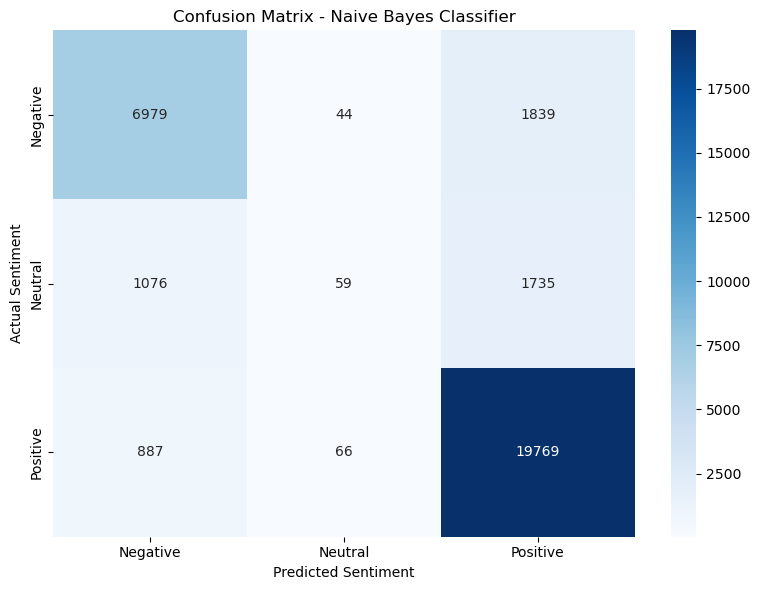

In [9]:
# Task 6: Print and display the Confusion Matrix

labels = ["Negative", "Neutral", "Positive"]

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("Confusion Matrix:")
print(cm)

# Display it as a heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix - Naive Bayes Classifier")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()